In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

sns.set_theme(style="whitegrid")

charts_path = Path("../reports/charts")
charts_path.mkdir(parents=True, exist_ok=True)

In [3]:
fund_master = pd.read_csv("../data/processed/fund_master_cleaned.csv")

nav_history = pd.read_csv("../data/processed/nav_history_cleaned.csv")

aum = pd.read_csv("../data/processed/aum_by_fund_house_cleaned.csv")

monthly_sip = pd.read_csv("../data/processed/monthly_sip_inflows_cleaned.csv")

category_inflows = pd.read_csv("../data/processed/category_inflows_cleaned.csv")

folio_count = pd.read_csv("../data/processed/industry_folio_count_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

holdings = pd.read_csv("../data/processed/portfolio_holdings_cleaned.csv")

In [4]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

aum["date"] = pd.to_datetime(aum["date"])

monthly_sip["month"] = pd.to_datetime(monthly_sip["month"])

category_inflows["month"] = pd.to_datetime(category_inflows["month"])

folio_count["month"] = pd.to_datetime(folio_count["month"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)

In [5]:
nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [6]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trends (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.15,
    line_width=0
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Market Correction",
    fillcolor="red",
    opacity=0.15,
    line_width=0
)

fig.show()

fig.write_image(
    charts_path / "nav_trend.png"
)

In [7]:
aum["year"] = aum["date"].dt.year

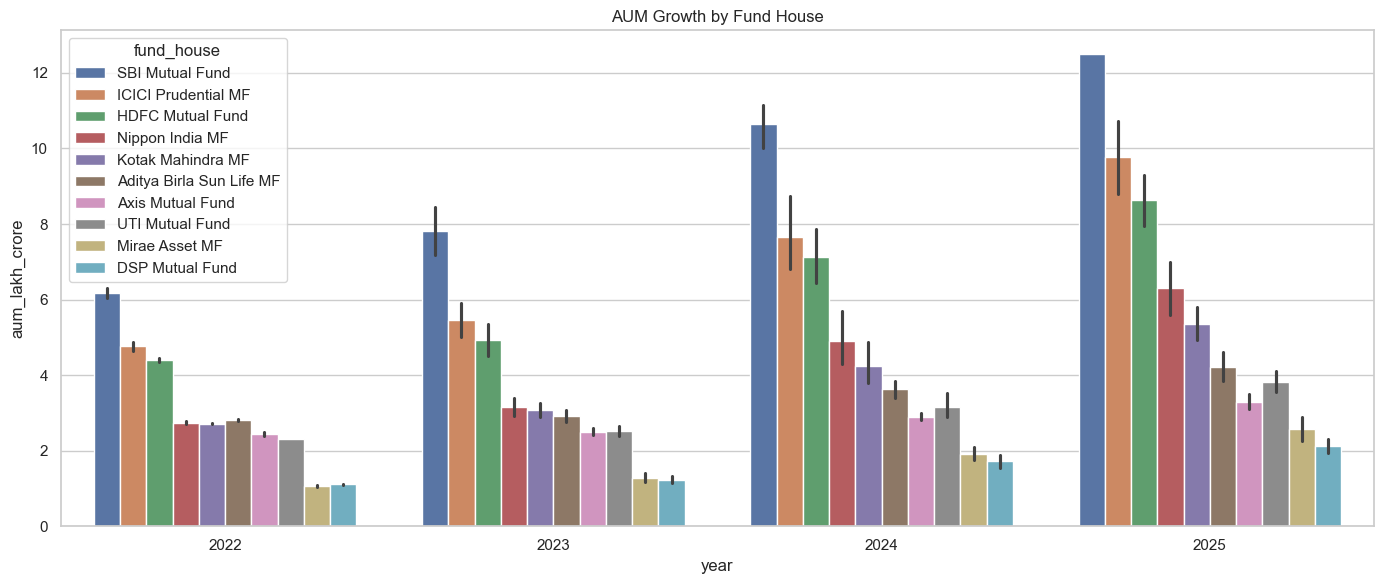

In [8]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.tight_layout()

plt.savefig(
    charts_path / "aum_growth.png"
)

plt.show()

In [10]:
fig = px.line(
    monthly_sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

max_row = monthly_sip.loc[
    monthly_sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=max_row["month"].strftime("%Y-%m"),
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High: ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True
)

fig.show()

fig.write_image(
    charts_path / "sip_trend.png"
)

In [11]:
heatmap_data = category_inflows.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

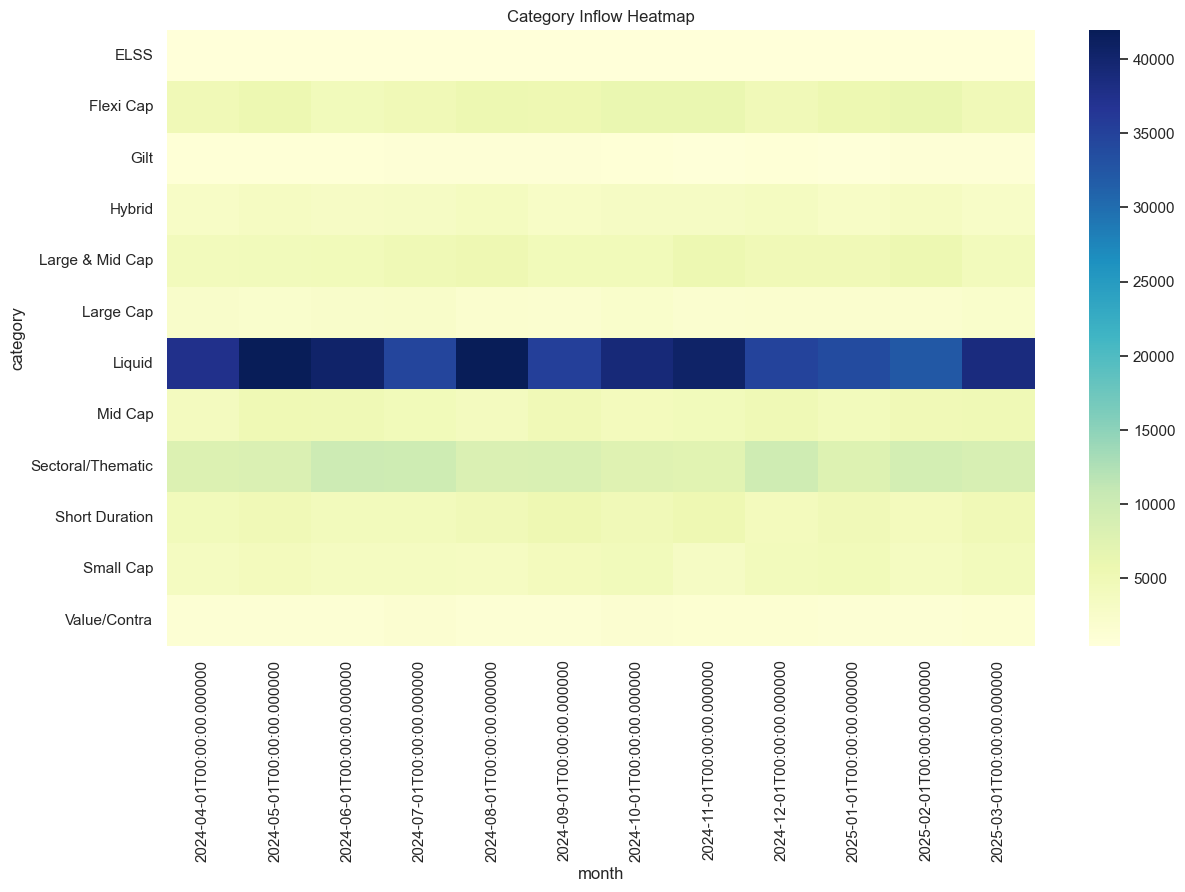

In [12]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    charts_path / "category_heatmap.png"
)

plt.show()

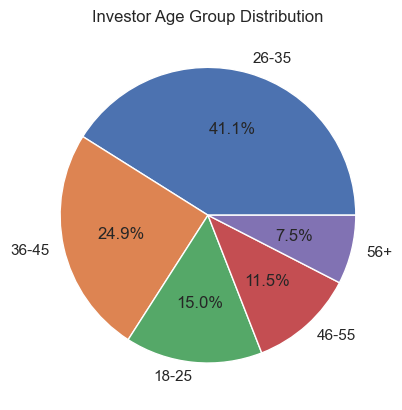

In [13]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    charts_path / "age_distribution.png"
)

plt.show()

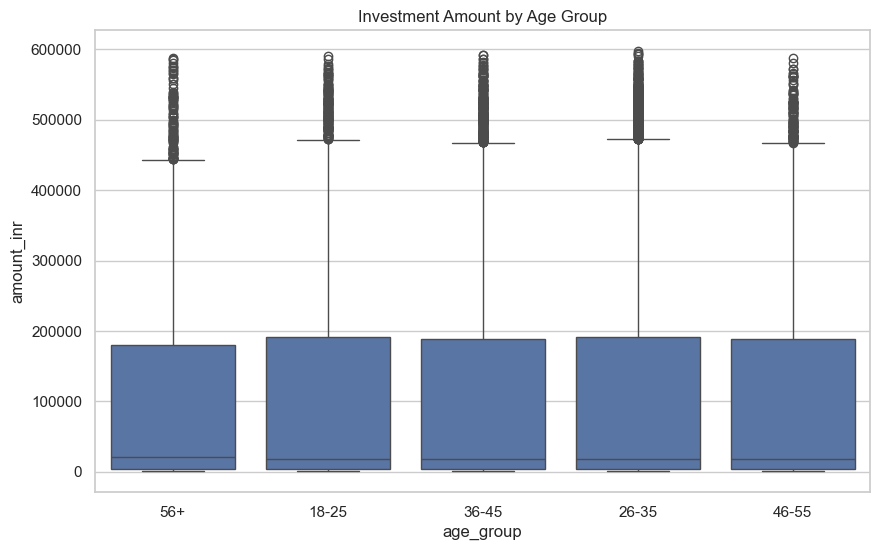

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.savefig(
    charts_path / "sip_boxplot.png"
)

plt.show()

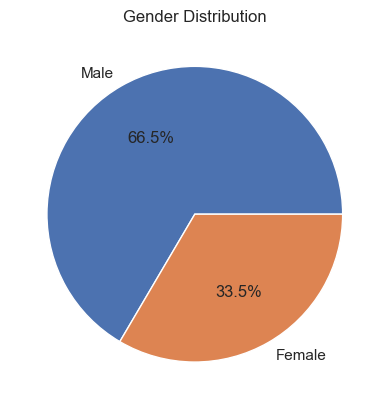

In [15]:
transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.savefig(
    charts_path / "gender_split.png"
)

plt.show()

In [16]:
state_amount = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

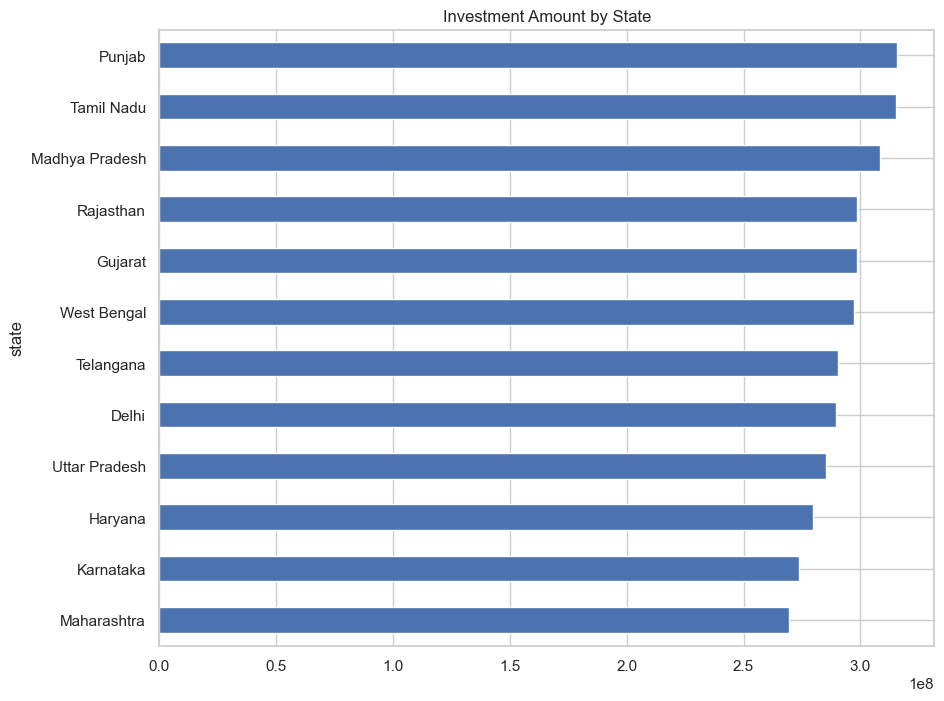

In [17]:
plt.figure(figsize=(10,8))

state_amount.plot(kind="barh")

plt.title("Investment Amount by State")

plt.savefig(
    charts_path / "state_distribution.png"
)

plt.show()

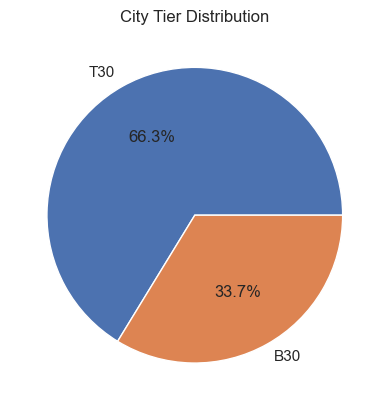

In [18]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("City Tier Distribution")

plt.savefig(
    charts_path / "city_tier.png"
)

plt.show()

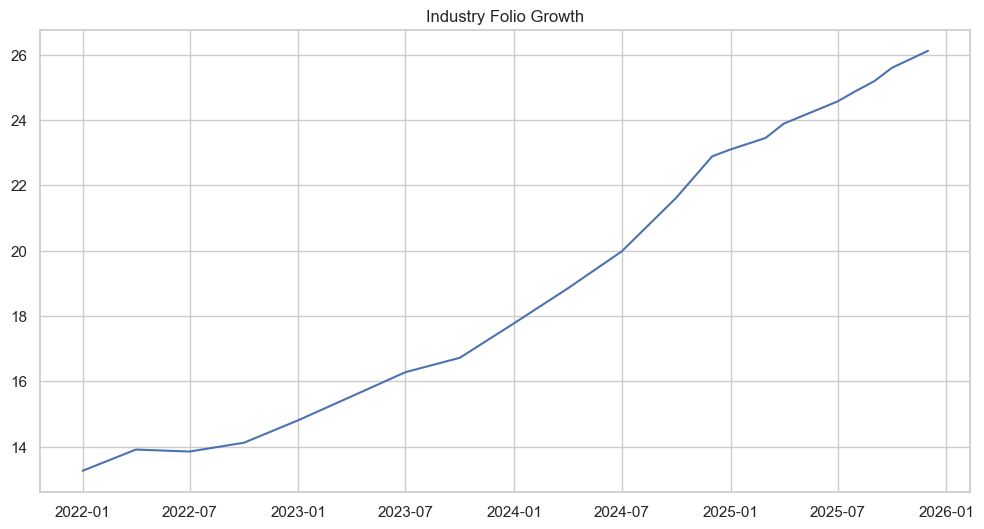

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    folio_count["month"],
    folio_count["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.savefig(
    charts_path / "folio_growth.png"
)

plt.show()

In [20]:
top10 = (
    nav_history["amfi_code"]
    .unique()[:10]
)

In [21]:
corr_data = nav_history[
    nav_history["amfi_code"].isin(top10)
]

In [22]:
pivot = corr_data.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [23]:
returns = pivot.pct_change()

corr = returns.corr()

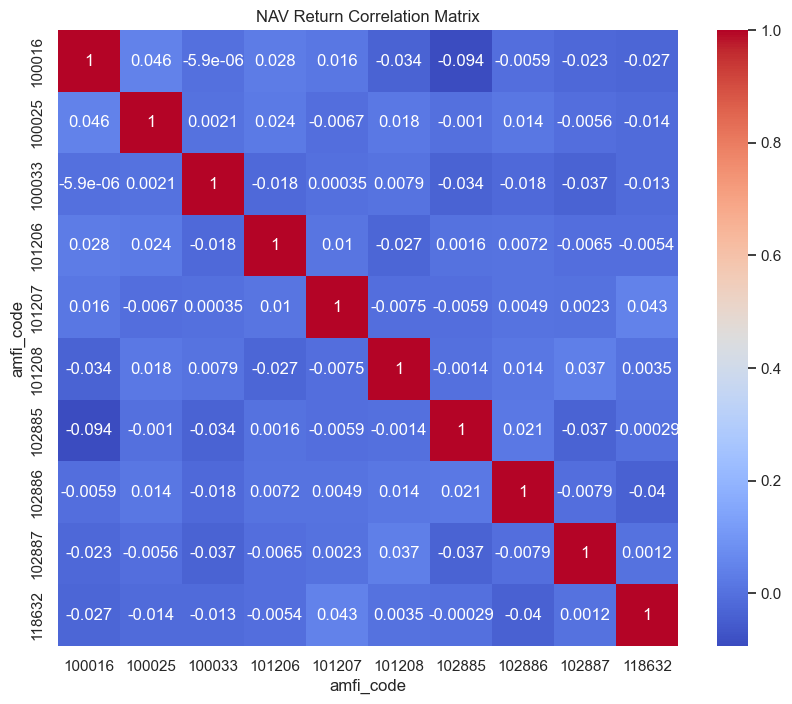

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.savefig(
    charts_path / "nav_correlation.png"
)

plt.show()

In [25]:
sector_weights = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

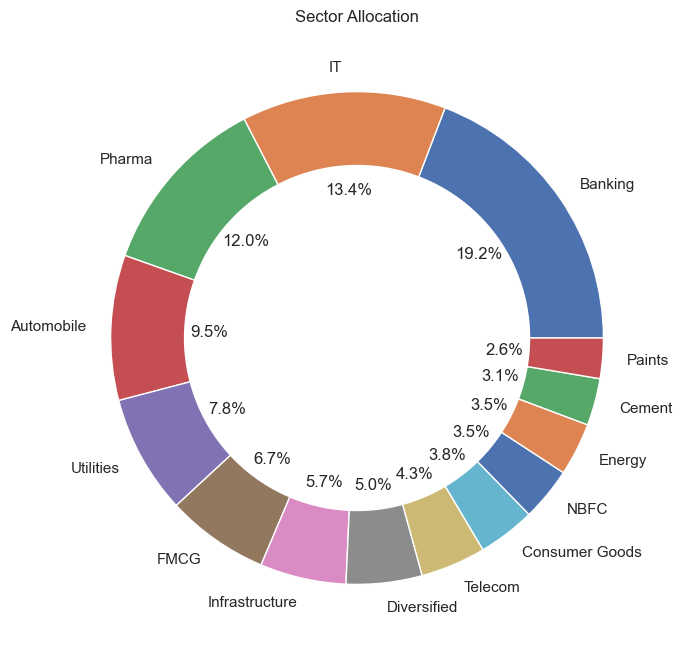

In [26]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title("Sector Allocation")

plt.savefig(
    charts_path / "sector_allocation.png"
)

plt.show()

# Additional EDA Analysis

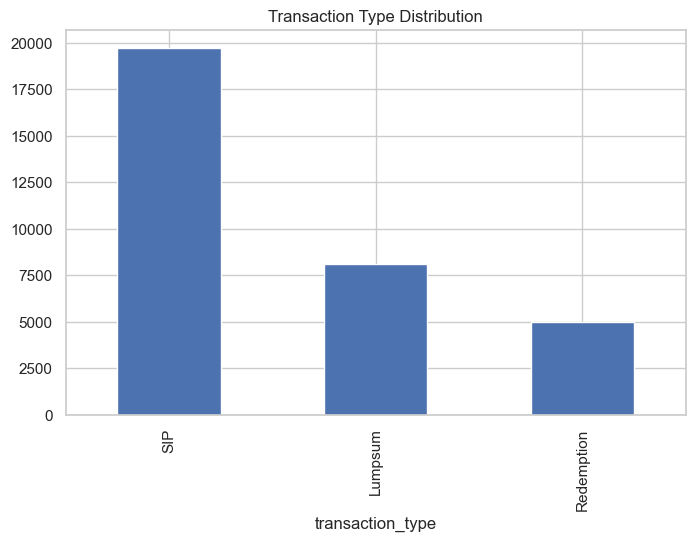

In [28]:
plt.figure(figsize=(8,5))

transactions["transaction_type"].value_counts().plot(
    kind="bar"
)

plt.title("Transaction Type Distribution")

plt.savefig(
    charts_path / "transaction_types.png"
)

plt.show()

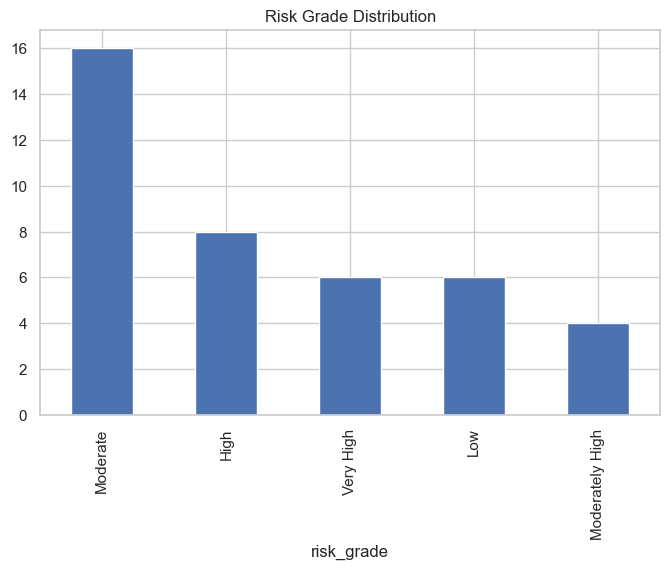

In [29]:
plt.figure(figsize=(8,5))

performance["risk_grade"].value_counts().plot(
    kind="bar"
)

plt.title("Risk Grade Distribution")

plt.savefig(
    charts_path / "risk_grades.png"
)

plt.show()

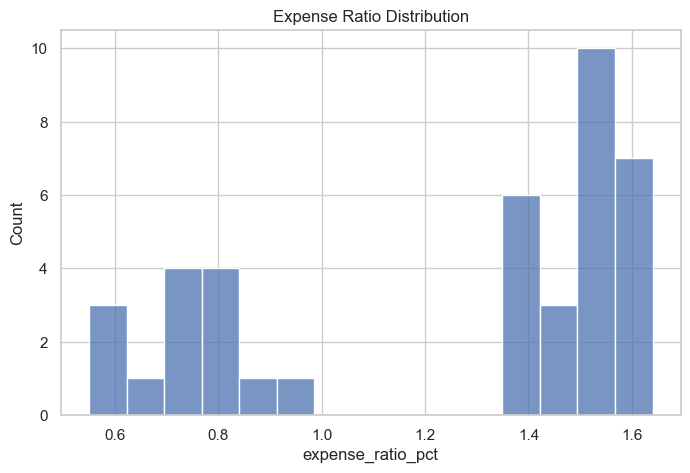

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15
)

plt.title("Expense Ratio Distribution")

plt.savefig(
    charts_path / "expense_ratio_distribution.png"
)

plt.show()

# Key EDA Findings

### Finding 1

Daily NAV values exhibited a generally upward trend across most mutual fund schemes between 2022 and 2025, indicating sustained long-term growth in fund performance (Chart 1: NAV Trend Analysis).

### Finding 2

Most schemes experienced accelerated NAV appreciation during 2023, reflecting favorable market conditions and a broad-based equity market bull run (Chart 1: NAV Trend Analysis).

### Finding 3

A temporary slowdown and correction phase was observed during 2024, highlighting the impact of market volatility on mutual fund valuations (Chart 1: NAV Trend Analysis).

### Finding 4

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), reinforcing its dominant position within the Indian mutual fund industry (Chart 2: AUM Growth Analysis).

### Finding 5

Monthly SIP inflows showed a strong upward trajectory throughout the study period, indicating increasing participation from retail investors (Chart 3: SIP Inflow Trend).

### Finding 6

The highest SIP inflow was recorded in December 2025, reaching approximately ₹31,002 crore, which reflects growing investor confidence in systematic investing (Chart 3: SIP Inflow Trend).

### Finding 7

Equity-oriented fund categories attracted substantially higher net inflows compared to debt and hybrid categories, suggesting stronger investor preference for growth-oriented investments (Chart 4: Category Inflow Heatmap).

### Finding 8

Investors belonging to middle-age groups contributed the largest share of investment activity, indicating higher participation from working professionals with stable income sources (Charts 5 and 6: Investor Demographics).

### Finding 9

Although T30 cities accounted for the majority of investments, B30 cities also demonstrated meaningful participation, highlighting the expanding reach of mutual fund adoption across India (Charts 8 and 9: Geographic Distribution).

### Finding 10

Sector allocation analysis revealed concentration in a limited number of sectors, indicating that equity mutual funds tend to maintain focused exposure toward key industries driving market performance (Chart 12: Sector Allocation Analysis).